# ============================================
# Phase 1. 어르신 유형 자동 분류 (PCA + K-Means)
# ============================================

In [6]:
# ---------- 1-1. 데이터 로딩 ----------
import numpy as np                                       # 숫자 배열 다루는 도구
import pandas as pd                                      # 표(엑셀 같은) 데이터 다루는 도구
import matplotlib.pyplot as plt                          # 그래프 그리는 도구

df = pd.read_csv('seniors.csv')                          # CSV 파일을 표로 읽어옴
print(df.shape)                                          # (1000, 12) - 1000명, 12개 컬럼
print(df.head())                                         # 위에서 5줄만 미리보기

(1000, 12)
  senior_id  age  care_level  fall_history  med_count  mmse_score  \
0     S0000   76           2             1          6          25   
1     S0001   73           3             1          8          22   
2     S0002   81           2             1          6          14   
3     S0003   75           3             0          6          20   
4     S0004   78           5             0          3          26   

   weight_change  monthly_visits  bp_variation  sleep_hours  meal_intake  \
0           0.23              15           9.3          6.1           66   
1           1.56              17           9.5          6.4           80   
2          -0.65               8          11.1          4.8           71   
3          -0.67              15          10.2          5.5           80   
4           0.38               7           5.7          7.3           76   

  _true_type  
0        mid  
1        mid  
2        mid  
3        mid  
4        low  


In [7]:
y_true = df['_true_type']                                # 정답 컬럼만 따로 빼둠 (검증용)
X = df.drop(columns=['senior_id', '_true_type'])         # 모델에 넣을 특성만 남김 (ID·정답 제거)
print(X.shape)                                           # (1000, 10) - 10개 특성

(1000, 10)


1단계 — 데이터 로딩과 분리
CSV 파일을 표(pandas.DataFrame)로 읽어들이고, 정답 컬럼(_true_type)은 따로 떼어 y_true에 둡니다. 모델에 들어가는 X에는 ID와 정답을 제외한 10개 특성만 남깁니다.

왜 정답을 떼어내나 — 실제 시설에선 이 정답 자체가 존재하지 않는 상황을 가정하기 때문입니다. 우리는 정답을 일부러 못 본 척하다가, 마지막에 검증용으로만 꺼냅니다.


용어: 특성(feature) = 모델 입력값. 우리 데이터에선 10개. 라벨(label) / y_true = 정답 분류.

In [8]:
# ---------- 1-2. 스케일링 ----------
from sklearn.preprocessing import StandardScaler         # 표준화 도구

scaler = StandardScaler()                                # 표준화 객체 생성
X_scaled = scaler.fit_transform(X)                       # 평균 0, 표준편차 1로 변환
print('평균:', X_scaled.mean(axis=0).round(2))           # 모든 컬럼이 0에 가까워야 정상
print('표준편차:', X_scaled.std(axis=0).round(2))        # 모든 컬럼이 1에 가까워야 정상


평균: [-0.  0.  0.  0.  0. -0.  0.  0. -0. -0.]
표준편차: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


2단계 — 스케일링
특성마다 단위가 제각각입니다. 나이는 70~90, 약 개수는 0~15, 식사량은 0~100. 이걸 그대로 두면 K-Means가 망가집니다.
왜 망가지나, 정확히 말씀드리면 — K-Means는 점 사이 거리를 유클리드 거리로 잽니다.
d(x,c)=(x1−c1)2+(x2−c2)2+⋯+(x10−c10)2 d(x, c) = \sqrt{(x_1 - c_1)^2 + (x_2 - c_2)^2 + \dots + (x_{10} - c_{10})^2 } d(x,c)=(x1​−c1​)2+(x2​−c2​)2+⋯+(x10​−c10​)2​
이 제곱합 안에서, 식사량 차이의 제곱(수천 단위)이 약 종류 차이의 제곱(수십 단위)을 수치적으로 압도합니다. 다 더하면 식사량이 합의 99%를 차지해서, 사실상 "식사량으로만 거리를 잰" 결과가 됩니다.
해결책: 표준화. 각 특성을 이렇게 변환합니다.
z=x−μσ z = \frac{x - \mu}{\sigma} z=σx−μ​
μ\mu
μ는 그 특성의 평균, σ\sigma
σ는 표준편차. 결과는 평균 0, 표준편차 1. 모든 특성이 같은 척도에서 더해지게 됩니다.

비유: 운동회에서 키와 몸무게로 등수 매길 때 단위를 통일하는 것. cm와 kg를 그냥 더하면 안 되니까요.


용어: 유클리드 거리 = 두 점 사이 직선거리. 표준화(StandardScaler) = z-score 변환. 분산 = 표준편차의 제곱. 데이터가 평균에서 얼마나 퍼져 있나.

In [9]:
# ---------- 1-3. PCA 차원 축소 ----------
from sklearn.decomposition import PCA                    # 주성분 분석 도구

pca = PCA(n_components=0.9)                              # 분산 90% 보존하도록 자동 결정
X_pca = pca.fit_transform(X_scaled)                      # 10차원을 핵심 축으로 압축
print(f'줄어든 차원 수: {X_pca.shape[1]}')               # 보통 5~7개로 줄어듦
print(f'보존된 분산: {pca.explained_variance_ratio_.sum():.3f}')   # 0.9 이상
print(f'각 주성분 기여도: {pca.explained_variance_ratio_.round(3)}')  # 첫 축이 가장 큼

줄어든 차원 수: 7
보존된 분산: 0.928
각 주성분 기여도: [0.632 0.069 0.068 0.057 0.041 0.033 0.029]


3단계 — PCA 차원 축소
어르신 한 명을 설명하는 데 정말 10개 특성이 다 필요할까요? 보통은 "신체 자립도"·"인지 상태" 같은 몇 개의 큰 축으로 압축됩니다. PCA가 이걸 어떻게 찾는지 정확히 다섯 단계입니다.
1) 중심화: 모든 특성에서 평균을 뺍니다. 데이터의 무게중심을 원점으로 옮기는 작업.
X~=X−Xˉ \tilde{X} = X - \bar{X} X~=X−Xˉ
2) 공분산 행렬 계산: 특성들이 얼마나 같이 움직이는지를 10×10 행렬로 만듭니다.
C=1n−1X~TX~ C = \frac{1}{n-1} \tilde{X}^T \tilde{X} C=n−11​X~TX~
대각선은 각 특성의 분산, 비대각선은 두 특성이 함께 변동하는 정도(공분산).
3) 고유벡터와 고유값 계산: Cv=λvCv = \lambda v
Cv=λv를 만족하는 벡터 vv
v(고유벡터)와 스칼라 λ\lambda
λ(고유값)를 찾습니다.
직관적으로 말씀드리면, 공분산 행렬의 고유벡터는 곧 "데이터가 가장 길게 퍼져 있는 방향" 입니다. 그 방향의 고유값은 그 방향으로 데이터가 얼마나 퍼져 있는지(=분산 크기).
4) 고유값이 큰 순으로 정렬: 큰 고유값 = 그 방향으로 변동이 많음 = 정보가 많은 축.
5) 상위 k개 고유벡터에 데이터 투영:
Xpca=X~⋅Vk X_{\text{pca}} = \tilde{X} \cdot V_k Xpca​=X~⋅Vk​
n_components=0.9는 이걸 합니다 — 고유값을 큰 순으로 누적해 더하다가, 합이 총합의 90% 이상이 되는 최소 kk
k를 자동으로 정합니다.
∑i=1kλi∑i=110λi≥0.9 \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{i=1}^{10} \lambda_i} \geq 0.9 ∑i=110​λi​∑i=1k​λi​​≥0.9
"정보 90% 보존"의 정확한 의미는 "원본 데이터 총 분산의 90%를 보존" 입니다. 분산이 큰 축일수록 데이터가 그 방향으로 길게 퍼졌다는 뜻이고, 우리는 퍼짐이 클수록 의미 있는 변동이 담겨 있다고 가정합니다.

비유: 사람을 여러 각도에서 찍는데, 특징이 가장 잘 드러나는 두세 각도만 골라 사진을 줄이는 것. 정면·옆모습은 정보가 많고, 30도 사선은 굳이 안 찍어도 됨.


"노이즈가 떨어진다"의 정확한 의미: 작은 고유값 축은 데이터가 그 방향으로 거의 안 퍼져 있어서, 패턴이라기보다 무작위 잡음일 가능성이 높습니다. 큰 고유값 축만 남기면 잡음이 같이 떨어집니다.


용어: 공분산 = 두 변수가 같이 움직이는 정도. 고유벡터/고유값 = 행렬을 곱해도 방향 안 바뀌고 크기만 λ\lambda
λ배 되는 특별한 벡터·스칼라. 주성분(PC) = PCA가 찾은 새 축들.

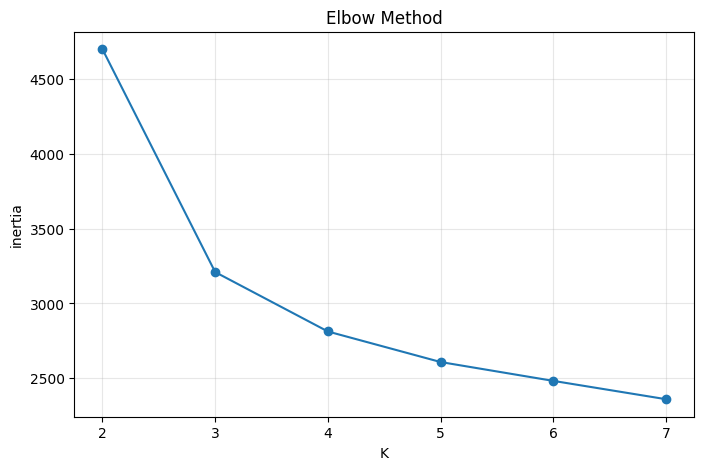

In [10]:
# ---------- 1-4. 엘보우로 K 찾기 ----------
from sklearn.cluster import KMeans                       # K-Means 군집 도구

inertia = []                                             # 각 K값의 inertia를 모을 리스트
for k in range(2, 8):                                    # K를 2부터 7까지 바꿔가며 시도
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)   # K값 바꿔 새 KMeans
    km_tmp.fit(X_pca)                                    # PCA로 줄인 데이터에 학습
    inertia.append(km_tmp.inertia_)                      # 군집 내 거리 제곱합 저장

plt.figure(figsize=(8, 5))                               # 그래프 도화지 생성
plt.plot(range(2, 8), inertia, 'o-')                     # K vs inertia 꺾은선 그래프
plt.xlabel('K')                                          # x축 이름
plt.ylabel('inertia')                                    # y축 이름
plt.title('Elbow Method')                                # 제목
plt.grid(alpha=0.3)                                      # 격자 (희미하게)
plt.show()                                               # 화면 출력

4단계 — 엘보우로 K 결정
K-Means는 무리 개수(K)를 사람이 미리 정해줘야 합니다. 어르신 유형이 2개인지 3개인지 5개인지 모르므로, 엘보우 방법을 씁니다.
K를 2~7로 바꿔가며 매번 K-Means를 돌리고, 그때의 inertia를 모읍니다.
inertia=∑k=1K∑xi∈Sk∥xi−ck∥2 \text{inertia} = \sum_{k=1}^{K} \sum_{x_i \in S_k} \|x_i - c_k\|^2 inertia=k=1∑K​xi​∈Sk​∑​∥xi​−ck​∥2
각 점이 자기 무리 중심까지의 거리를 제곱해서 다 더한 값. 작을수록 무리들이 빽빽이 모인 것입니다.
왜 엘보우 모양이 생기는가, 정확히:

K가 진짜 그룹 수보다 작을 때 → 한 무리에 서로 다른 부류가 섞여 있으므로,
K를 늘리면 섞인 부류가 분리되며 inertia가 크게 감소.
K가 진짜 그룹 수 이상일 때 → 같은 부류 안 점들을 굳이 또 쪼개는 상황. 이미 가까운 점들이라 쪼개봤자 감소폭이 미미.

이 두 구간의 감소 속도 차이가 그래프에 꺾임을 만듭니다. 그 꺾이는 지점이 적정 K입니다.
이 데이터는 실제 유형이 3개니까 K=3
K=3에서 꺾일 것입니다.

용어: inertia = 군집 내 거리 제곱합. K-Means가 최소화하려는 목적함수. 
엘보우 = inertia 감소가 둔화되는 지점.



In [11]:
# ---------- 1-5. K-Means 최종 적용 ----------
optimal_k = 3                                            # 엘보우에서 꺾이는 지점 확인 후 결정
km = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)   # 최종 모델
km.fit(X_pca)                                            # 학습

unique, counts = np.unique(km.labels_, return_counts=True)      # 군집별 인원 집계
print('군집별 인원:', dict(zip(unique, counts)))
print('수렴 반복 횟수:', km.n_iter_)

군집별 인원: {np.int32(0): np.int64(500), np.int32(1): np.int64(147), np.int32(2): np.int64(353)}
수렴 반복 횟수: 3


5단계 — K-Means 최종 학습
엘보우에서 정한 K(3)로 최종 K-Means를 돌립니다. 알고리즘은 두 단계의 반복입니다.
초기화: K-Means++ 방식으로 중심 c1,c2,c3c_1, c_2, c_3
c1​,c2​,c3​를 영리하게 초기화 (서로 멀리 떨어진 점들로).
배정 단계 (Assignment): 모든 점 xix_i
xi​를 가장 가까운 중심에 할당.
cluster(xi)=arg⁡min⁡k∥xi−ck∥2 \text{cluster}(x_i) = \arg\min_{k} \|x_i - c_k\|^2 cluster(xi​)=argkmin​∥xi​−ck​∥2
각 점에 대해 3개 중심까지 거리 제곱을 다 재고, 가장 작은 거리의 중심 번호를 라벨로 부여.
갱신 단계 (Update): 각 무리에 속한 점들의 평균 좌표로 중심을 이동.
ck=1∣Sk∣∑xi∈Skxi c_k = \frac{1}{|S_k|} \sum_{x_i \in S_k} x_i ck​=∣Sk​∣1​xi​∈Sk​∑​xi​
종료 조건 (수렴): 다음 중 하나가 만족되면 멈춤.

모든 점의 라벨이 더 이상 안 바뀜
중심점들 이동량이 임계값(tol, sklearn 기본 1e-4) 이하
최대 반복 횟수(max_iter, 기본 300) 도달

왜 항상 수렴하나 — 두 단계 모두 inertia를 단조 감소시킵니다. 배정 단계는 각 점을 더 가까운 중심에 보냄으로써, 갱신 단계는 중심을 그 무리 평균(거리 제곱합 최소화 지점)으로 옮김으로써. inertia는 0 이상이고 단조 감소이니 반드시 어딘가에서 멈춥니다.
다만 전역 최적은 아닙니다. 초기값에 따라 다른 곳에 정착할 수 있어서, n_init=10이면 10번 다른 초기값으로 돌려보고 inertia 가장 작은 결과를 채택합니다.

비유: 운동장에 반장 3명을 세우고, ① 학생들이 가까운 반장에게 가고 → ② 반장이 자기 무리 한가운데로 이동 → ③ 반복. 더 이상 무리 구성이 안 바뀌면 끝.


용어: centroid(중심점) = 무리의 평균 좌표. 수렴 = 더 이상 변화 없는 상태. labels_ = 각 데이터의 무리 번호.

In [12]:
# ---------- 1-6. 정답과 비교 (교차표) ----------
cross = pd.crosstab(km.labels_, y_true)                  # 군집번호 × 실제유형 교차표
print('\n교차표 (군집 vs 정답):')
print(cross)                                             # 대각선이 크면 잘 맞춘 것


교차표 (군집 vs 정답):
_true_type  high  low  mid
row_0                     
0              0  500    0
1            147    0    0
2              3    0  350


이제 숨겨뒀던 정답을 꺼냅니다. pd.crosstab(km.labels_, y_true)로 "K-Means 군집 0번이 실제로 어느 유형(low/mid/high)에 몰려 있나"를 표로 봅니다.
예시:
y_true   high  low  mid
labels_
0          0   485   15
1         12    10  335
2        138     5   12

→ 군집 1번 ≈ low, 군집 2번 ≈ high, 군집 3번 ≈ mid. 대각선 외 칸이 작을수록 잘 맞춘 것.
군집 번호와 정답 이름이 같을 필요는 없습니다. K-Means는 번호를 임의로 매기므로, 군집 0번이 'high'일 수도 'low'일 수도 있습니다. 우리는 매칭 패턴만 봅니다.

용어: 교차표(crosstab) = 두 분류 결과의 매칭을 셀로 표현한 표. 혼동행렬은 교차표의 이진 분류 버전.



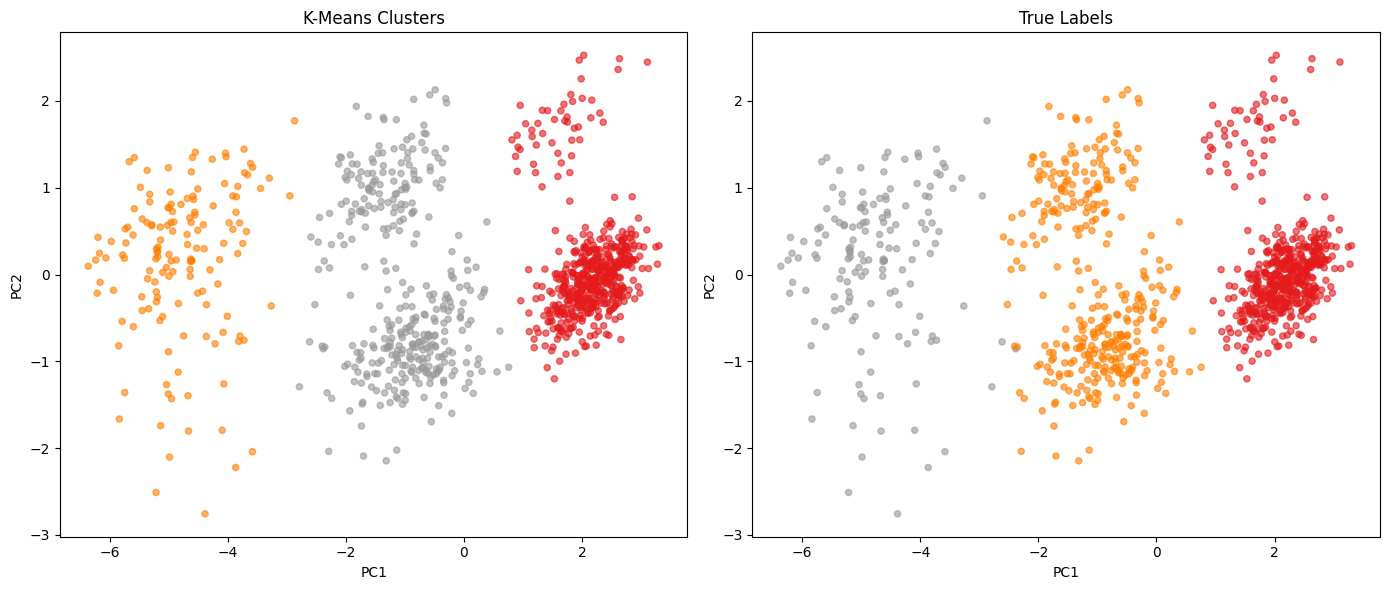

In [15]:
# ---------- 1-7. 2D 시각화 ----------
pca_2d = PCA(n_components=2)                             # 시각화 전용 2차원 PCA 별도 생성
X_2d = pca_2d.fit_transform(X_scaled)                    # 화면에 그릴 수 있게 2차원으로

fig, axes = plt.subplots(1, 2, figsize=(14, 6))          # 한 줄짜리 도화지 2칸

# 왼쪽: K-Means가 나눈 결과
axes[0].scatter(X_2d[:, 0], X_2d[:, 1],
                c=km.labels_, cmap='Set1', alpha=0.6, s=20)     # 군집 번호로 색칠
axes[0].set_title('K-Means Clusters')
axes[0].set_xlabel('PC1')                                # 첫 번째 주성분
axes[0].set_ylabel('PC2')                                # 두 번째 주성분

# 오른쪽: 실제 정답
type_to_num = {'low': 0, 'mid': 1, 'high': 2}            # 문자열 정답을 숫자로 (색 매핑용)
axes[1].scatter(X_2d[:, 0], X_2d[:, 1],
                c=y_true.map(type_to_num), cmap='Set1', alpha=0.6, s=20)
axes[1].set_title('True Labels')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()                                       # 두 칸 간격 자동 조정
plt.show()




7단계 — 2D 시각화
한 장으로 보여드릴 그림을 만듭니다. PCA를 새로 하나 만듭니다 — 이번엔 n_components=2로 무조건 2차원까지 줄입니다.
3단계의 PCA(분산 90% 보존, 5~7차원)는 학습용이고, 7단계의 PCA(2차원 고정)는 시각화용입니다. 두 목적이 충돌하므로 분리합니다.
학습용 PCA (3단계)시각화용 PCA (7단계)n_components0.92결과 차원5~7차원2차원정보 손실~10%50% 이상 가능목적K-Means 정확도사람 눈으로 확인
plt.subplots(1, 2)로 도화지를 두 칸으로 나누고, 왼쪽엔 K-Means가 색칠한 결과(c=km.labels_), 오른쪽엔 실제 정답(c=y_true)으로 색칠. 두 그림 덩어리 모양이 비슷하면 K-Means가 일을 잘했다는 시각적 증거입니다.

K-Means는 무리 번호를 임의로 매기기 때문입니다. 정답이 'low/mid/high'든 'apple/banana/pineapple'이든 K-Means는 그걸 모르고, 그냥 "내가 찾은 첫 무리는 0번, 두 번째는 1번, 세 번째는 2번"이라고 본인 마음대로 번호를 붙입니다.
그래서 두 그림이 이렇게 됩니다.
같은 위치의 덩어리왼쪽 (K-Means)오른쪽 (정답)좌상단 덩어리군집 0번 → 빨강'high' → 파랑중앙 덩어리군집 1번 → 파랑'mid' → 초록우하단 덩어리군집 2번 → 초록'low' → 빨강
같은 덩어리인데 번호가 다르고, cmap='Set1'이 번호별로 색을 매핑하니까 색이 어긋나 보이는 것입니다. 모양(점 위치·덩어리 위치)은 같습니다.

In [16]:
# ---------- 1-8. 군집별 특성 해석 ----------
df_with_cluster = X.copy()                               # 원본 X를 복사
df_with_cluster['cluster'] = km.labels_                  # 군집 번호 컬럼 추가

profile = df_with_cluster.groupby('cluster').mean().round(2)    # 군집별 평균 특성
print('\n군집별 평균 특성:')
print(profile)


군집별 평균 특성:
           age  care_level  fall_history  med_count  mmse_score  \
cluster                                                           
0        72.01        4.62          0.10       2.95       25.85   
1        86.23        1.54          0.84       9.27       12.03   
2        79.83        2.85          0.37       5.87       20.02   

         weight_change  monthly_visits  bp_variation  sleep_hours  meal_intake  
cluster                                                                         
0                 0.01            8.00          4.97         7.04        85.01  
1                -2.18           22.25         18.23         4.91        56.13  
2                -0.43           14.95          9.92         5.99        69.63  


8단계 — 군집 해석과 명명
비지도학습의 진짜 가치가 드러나는 곳입니다. df.groupby('cluster').mean()으로 각 군집의 평균 특성을 표로 뽑으면 예를 들어 이렇게 나옵니다.
cluster나이낙상이력약 종류MMSE식사량072.30.103.126.284.8179.80.416.219.870.5285.90.819.112.154.7
이 표를 보고 사람이 결론을 내립니다.

0번 군집 = 평균 72세, 낙상 10%, 약 3개, 인지 정상 → 저위험
1번 군집 = 평균 80세, 낙상 41%, 약 6개, 인지 저하 → 중위험
2번 군집 = 평균 86세, 낙상 81%, 약 9개, 인지 중증 → 고위험

알고리즘은 군집을 만들었고, 이름은 사람이 붙입니다. 원장님과 함께 이 표를 보고 "맞아, 우리 시설 어르신은 이렇게 세 부류로 나뉘지" 확인받는 것이 비지도학습이 실무에서 끝나는 모습입니다.
그리고 한 번 이름이 붙으면, 이게 곧 지도학습 라벨이 됩니다. 신규 어르신 데이터는 pipeline.predict(new_X) 한 줄로 자동 분류 가능. 콜드스타트 해결입니다.

용어: 콜드스타트 = 라벨 0건 상태. groupby = 컬럼 값 기준으로 묶어서 집계.

전체 한 줄 요약
정답 라벨이 없는 어르신 1,000명을, 스케일링 → PCA로 압축 → 엘보우로 K 결정 → K-Means로 군집화 → 정답과 교차표로 검증 → 2D 시각화 → 사람이 군집에 이름 붙이기, 이 8단계로 자동 분류한다. 각 단계는 수학적으로 다음 절차다 — z-score 표준화, 공분산 행렬의 고유벡터 추출, inertia 최소화의 단조 감소 보장 반복, 누적 분산 비율 기반 차원 결정.